In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [42]:
f_pd = uproot.open(
    "/pscratch/sd/k/kgreif/data/Pseudodata_SherpaDY_PowhegPythiaTop_June2025_shuffled_topLogit.root"
)
t_pd = f_pd["OmniTree"]

pass190_pd = ak.to_numpy(t_pd["pass190"].array())
is_top_pd = ak.to_numpy(t_pd["isTop"].array())
logit_pd = ak.to_numpy(t_pd["isTop_logit"].array())

logit_pd = logit_pd[pass190_pd == 1]

In [43]:
f_top = uproot.open(
    "/pscratch/sd/k/kgreif/data/ZjetOmnifold_14May2025_Background_Sherpa2212_AllTop_WithTracks_slim_Systematics_topLogit.root"
)
t_top = f_top["OmniTree"]

pass190_top = ak.to_numpy(t_top["pass190"].array())
logit_top = ak.to_numpy(t_top["isTop_logit"].array())
weight_top = ak.to_numpy(t_top["weight"].array())

logit_top = logit_top[pass190_top == 1]
weight_top = weight_top[pass190_top == 1]

In [44]:
logit_pd_minus_top = np.concatenate([logit_pd, logit_top])
weights_pd_minus_top = np.concatenate([np.ones(len(logit_pd)), -1 * weight_top])

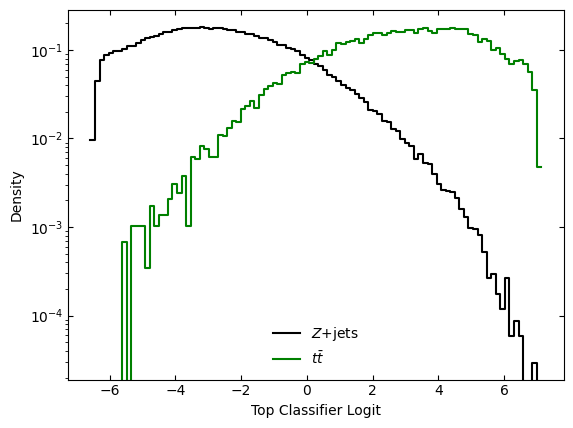

In [45]:
max_logit = max(logit_pd.max(), logit_top.max())
min_logit = min(logit_pd.min(), logit_top.min())
bins = np.linspace(min_logit, max_logit, 100)
h_logit_pd, _ = np.histogram(logit_pd, bins=bins, density=True)
h_logit_top, _ = np.histogram(logit_top, bins=bins, density=True)

plot_h_logit_pd = np.concatenate([h_logit_pd, h_logit_pd[-1:]])
plot_h_logit_top = np.concatenate([h_logit_top, h_logit_top[-1:]])

plt.plot(bins, plot_h_logit_pd, drawstyle="steps-post", label=r"$Z$+jets", color="black")
plt.plot(bins, plot_h_logit_top, drawstyle="steps-post", label=r"$t\bar{t}$", color="green")
plt.yscale("log")
ax = plt.gca()
ax.tick_params(axis="both", direction="in", top=True, right=True)
plt.ylabel("Density")
plt.xlabel("Top Classifier Logit")
plt.legend(frameon=False)
# plt.savefig("./plot_storage/top_subtraction/logit_histogram.pdf", dpi=300)
plt.show()

In [64]:
# reweighting_list = ["fiery-bush", "giddy-bird", "polar-blaze", "swift-rain", "divine-microwave", "leafy-galaxy", "fancy-jazz"]
# # reweighting_list = ["faithful-sky"]
# all_weights = np.zeros((len(reweighting_list), len(logit_pd)))
# for i, name in enumerate(reweighting_list):
#     reweighting = np.load(f"{name}.npz")
#     all_weights[i] = reweighting["reweighting"]
# new_weights = np.mean(all_weights, axis=0).clip(max=5)
new_weights_file = np.load("./weight_storage/bsv3_001.npz")
new_weights = new_weights_file["pd_weights"]
new_weights = new_weights.clip(max=1.0)

In [65]:
print(f"Mean of new weights: {np.mean(new_weights)}")
print(f"Std of new weights: {np.std(new_weights)}")


Mean of new weights: 0.9961644411087036
Std of new weights: 0.01585281640291214


In [66]:
bins = np.linspace(logit_pd.min(), logit_pd.max(), 100)
h_logit_pd, _ = np.histogram(logit_pd, bins=bins, density=True)
h_logit_pd_minus_top, _ = np.histogram(logit_pd_minus_top, bins=bins, density=True, weights=weights_pd_minus_top)
h_logit_pd_rw, _ = np.histogram(logit_pd, bins=bins, density=True, weights=new_weights.clip(max=10))

plot_h_logit_pd = np.concatenate([h_logit_pd, h_logit_pd[-1:]])
plot_h_logit_pd_minus_top = np.concatenate([h_logit_pd_minus_top, h_logit_pd_minus_top[-1:]])
plot_h_logit_pd_rw = np.concatenate([h_logit_pd_rw, h_logit_pd_rw[-1:]])

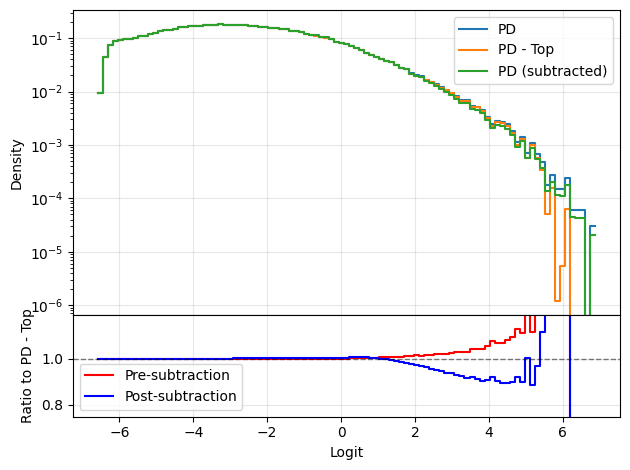

In [67]:
# Create figure with two subplots: main plot and ratio pad
fig, (ax_main, ax_ratio) = plt.subplots(
    2, 1, figsize=(6.4, 4.8), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}
)

# Main histogram plot
ax_main.plot(bins, plot_h_logit_pd, drawstyle="steps-post", label="PD")
ax_main.plot(bins, plot_h_logit_pd_minus_top, drawstyle="steps-post", label="PD - Top")
ax_main.plot(bins, plot_h_logit_pd_rw, drawstyle="steps-post", label="PD (subtracted)")
ax_main.set_yscale("log")
ax_main.legend()
ax_main.set_ylabel("Density")
ax_main.grid(True, alpha=0.3)

# Remove x-axis labels from main plot
ax_main.set_xticklabels([])

# Calculate ratio (avoid division by zero)
ratio_pre = np.divide(
    plot_h_logit_pd,
    plot_h_logit_pd_minus_top,
    out=np.zeros_like(plot_h_logit_pd_minus_top),
    where=plot_h_logit_pd_minus_top != 0,
)
ratio_post = np.divide(
    plot_h_logit_pd_rw,
    plot_h_logit_pd_minus_top,
    out=np.zeros_like(plot_h_logit_pd_minus_top),
    where=plot_h_logit_pd_minus_top != 0,
)

# Ratio pad
ax_ratio.plot(bins, ratio_pre, drawstyle="steps-post", color="red", linewidth=1.5, label="Pre-subtraction")
ax_ratio.plot(bins, ratio_post, drawstyle="steps-post", color="blue", linewidth=1.5, label="Post-subtraction")
ax_ratio.axhline(y=1, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax_ratio.set_ylabel("Ratio to PD - Top")
ax_ratio.set_xlabel("Logit")
ax_ratio.grid(True, alpha=0.3)
ax_ratio.legend()

# Set reasonable y-limits for ratio (adjust as needed)
ratio_nonzero_pre = ratio_pre[ratio_pre != 0]
if len(ratio_nonzero_pre) > 0:
    ratio_min_pre, ratio_max_pre = np.percentile(ratio_nonzero_pre, [5, 95])
    ax_ratio.set_ylim(max(0, ratio_min_pre * 0.95), ratio_max_pre * 1.05)
ratio_nonzero_post = ratio_post[ratio_post != 0]
if len(ratio_nonzero_post) > 0:
    ratio_min_post, ratio_max_post = np.percentile(ratio_nonzero_post, [5, 95])
    ax_ratio.set_ylim(max(0, ratio_min_post * 0.95), ratio_max_post * 1.05)

plt.tight_layout()
plt.show()

In [68]:
plot_obs = ["Ntracks", "HT_tracks", "pT_ll", "pT_trackj1", "pT_trackj2", "y_ll", "m_trackj1", "m_trackj2", "tau1_trackj1", "tau2_trackj1", "tau1_trackj2", "tau2_trackj2"]

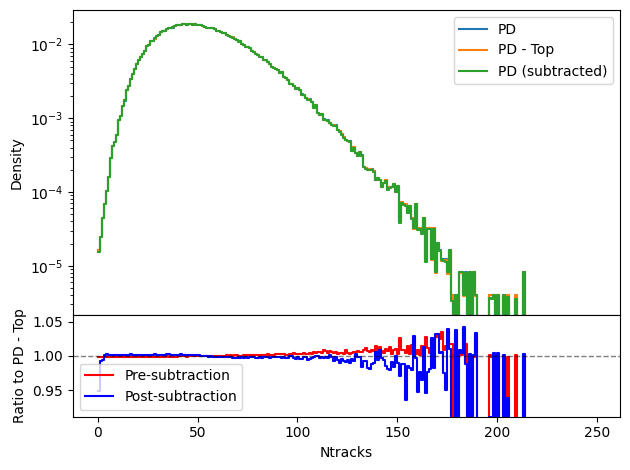

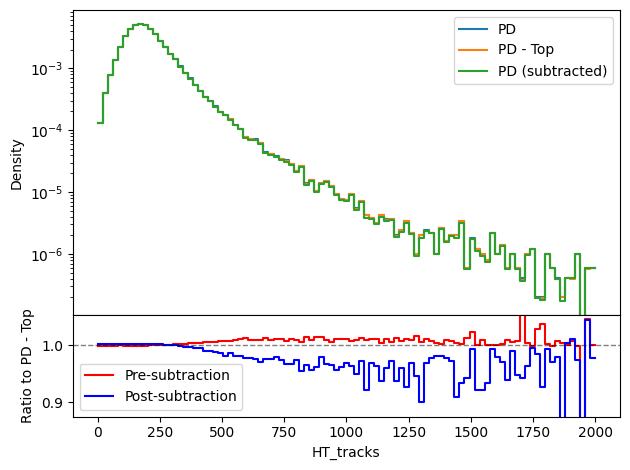

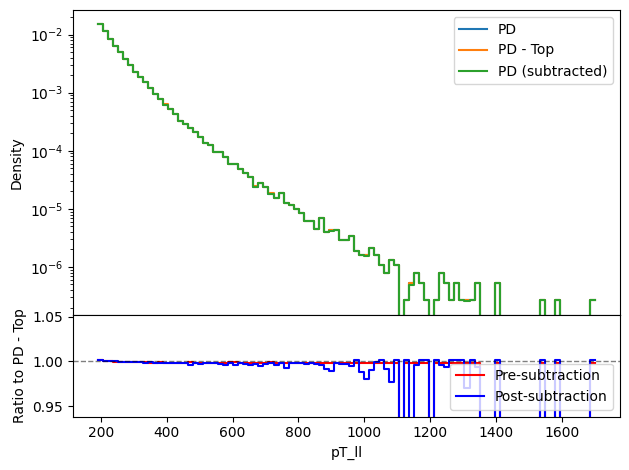

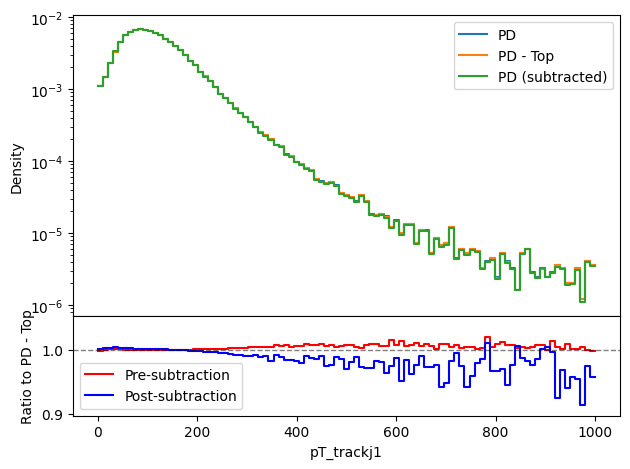

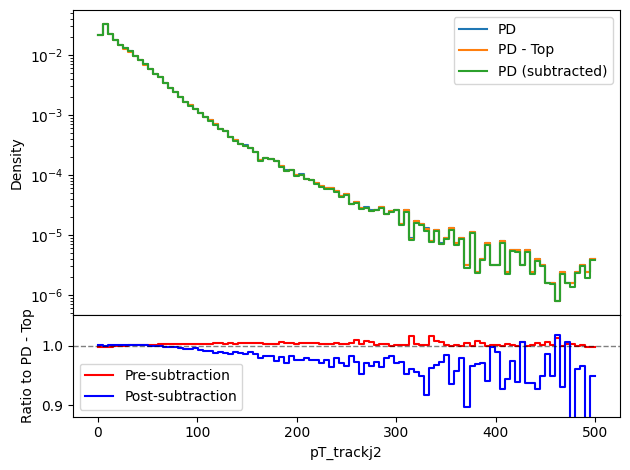

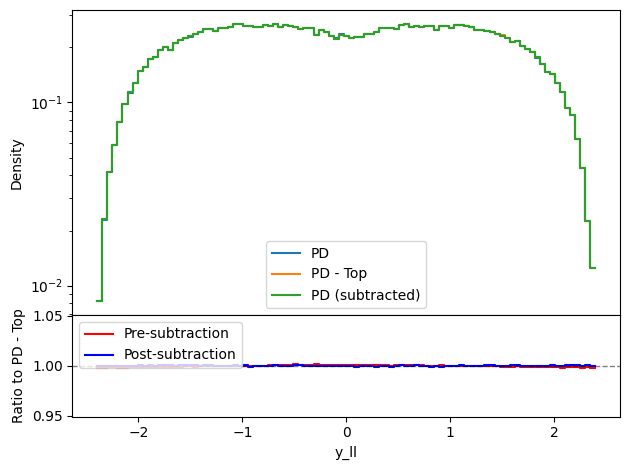

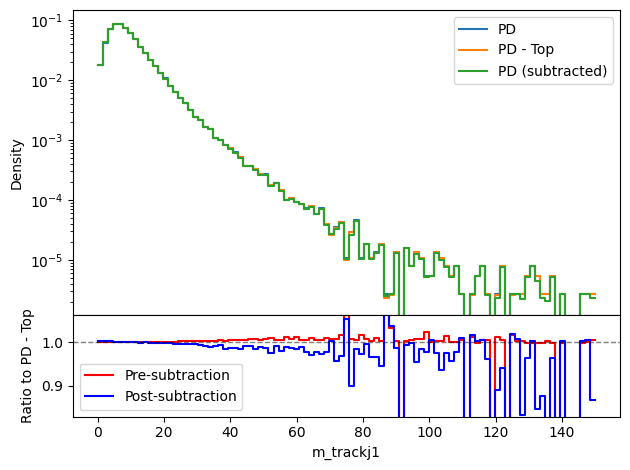

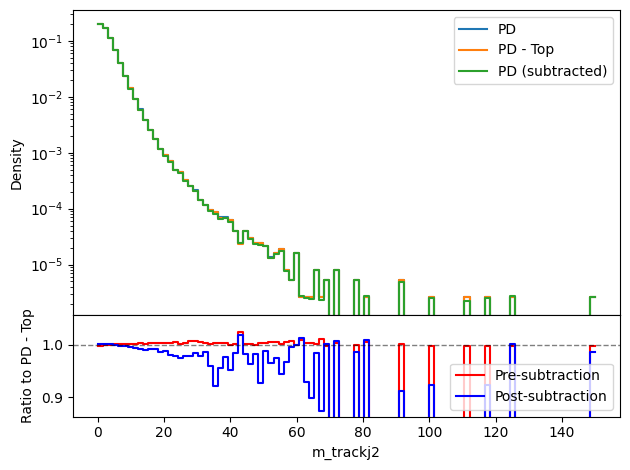

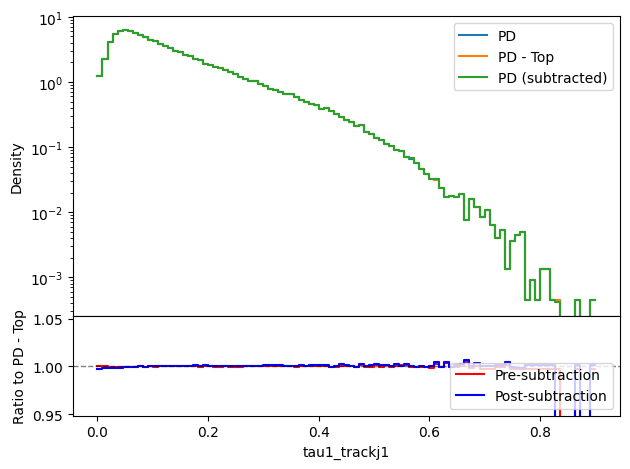

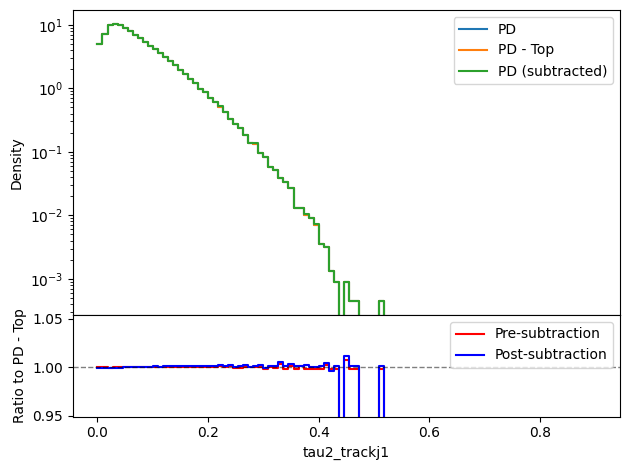

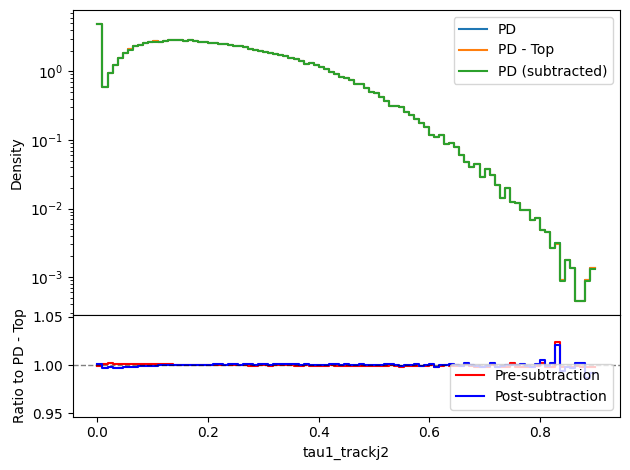

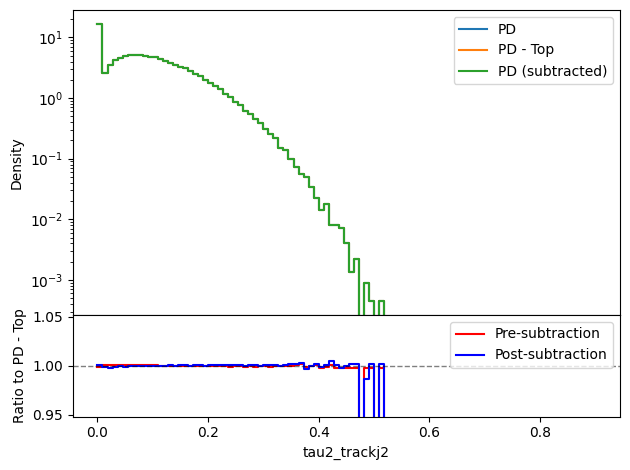

In [69]:
for obs in plot_obs:

    obs_pd = ak.to_numpy(t_pd[obs].array())
    obs_top = ak.to_numpy(t_top[obs].array())
    obs_top = obs_top[pass190_top == 1]

    obs_pd_minus_top = np.concatenate([obs_pd, obs_top])
    weights_pd_minus_top = np.concatenate([np.ones(len(obs_pd)), -1 * weight_top])

    if obs == "HT_tracks":
        max_obs = 2000
    elif obs == "pT_trackj1":
        min_obs = 0
        max_obs = 1000
    elif obs == "pT_trackj2":
        min_obs = 0
        max_obs = 500
    elif obs == "m_trackj1":
        min_obs = 0
        max_obs = 150
    elif obs == "m_trackj2":
        min_obs = 0
        max_obs = 150
    elif "tau" in obs:
        min_obs = 0
        max_obs = 0.9
    else:
        min_obs = min(obs_pd_minus_top.min(), obs_top.min())
        max_obs = max(obs_pd_minus_top.max(), obs_top.max())
        
    bins = np.linspace(min_obs, max_obs, 100)
    if obs == "Ntracks":
        bins = np.arange(0, 250, 1)
    h_obs_pd, _ = np.histogram(obs_pd, bins=bins, density=True)
    h_obs_pd_minus_top, _ = np.histogram(
        obs_pd_minus_top, bins=bins, density=True, weights=weights_pd_minus_top
    )
    h_obs_pd_rw, _ = np.histogram(
        obs_pd, bins=bins, density=True, weights=new_weights
    )

    plot_h_obs_pd = np.concatenate([h_obs_pd, h_obs_pd[-1:]])
    plot_h_obs_pd_minus_top = np.concatenate(
        [h_obs_pd_minus_top, h_obs_pd_minus_top[-1:]]
    )
    plot_h_obs_pd_rw = np.concatenate([h_obs_pd_rw, h_obs_pd_rw[-1:]])

    # Make ratio plot
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, figsize=(6.4, 4.8), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}
    )

    # Main histogram plot
    ax_main.plot(bins, plot_h_obs_pd, drawstyle="steps-post", label="PD")
    ax_main.plot(bins, plot_h_obs_pd_minus_top, drawstyle="steps-post", label="PD - Top")
    ax_main.plot(bins, plot_h_obs_pd_rw, drawstyle="steps-post", label="PD (subtracted)")
    ax_main.set_yscale("log")
    ax_main.legend()
    ax_main.set_ylabel("Density")

    # Remove x-axis labels from main plot
    ax_main.set_xticklabels([])

    # Calculate ratio (avoid division by zero)
    ratio_pre = np.divide(
        plot_h_obs_pd,
        plot_h_obs_pd_minus_top,
        out=np.zeros_like(plot_h_obs_pd_minus_top),
        where=plot_h_obs_pd_minus_top != 0,
    )
    ratio_post = np.divide(
        plot_h_obs_pd_rw,
        plot_h_obs_pd_minus_top,
        out=np.zeros_like(plot_h_obs_pd_minus_top),
        where=plot_h_obs_pd_minus_top != 0,
    )

    # Ratio pad
    ax_ratio.plot(
        bins,
        ratio_pre,
        drawstyle="steps-post",
        color="red",
        linewidth=1.5,
        label="Pre-subtraction",
    )
    ax_ratio.plot(
        bins,
        ratio_post,
        drawstyle="steps-post",
        color="blue",
        linewidth=1.5,
        label="Post-subtraction",
    )
    ax_ratio.axhline(y=1, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax_ratio.set_ylabel("Ratio to PD - Top")
    ax_ratio.set_xlabel(obs)
    ax_ratio.legend()

    # Set reasonable y-limits for ratio (adjust as needed)
    ratio_nonzero_pre = ratio_pre[ratio_pre != 0]
    if len(ratio_nonzero_pre) > 0:
        ratio_min_pre, ratio_max_pre = np.percentile(ratio_nonzero_pre, [5, 95])
        ax_ratio.set_ylim(max(0, ratio_min_pre * 0.95), ratio_max_pre * 1.05)
    ratio_nonzero_post = ratio_post[ratio_post != 0]
    if len(ratio_nonzero_post) > 0:
        ratio_min_post, ratio_max_post = np.percentile(ratio_nonzero_post, [5, 95])
        ax_ratio.set_ylim(max(0, ratio_min_post * 0.95), ratio_max_post * 1.05)

    plt.tight_layout()
    plt.show()